### EXPLORATORY DATA ANALYSIS (EDA)

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [122]:
# Load the Dataset
df = pd.read_csv(
    "DataCoSupplyChain_Cleaned.csv",
    parse_dates=["order_date_dateorders", "shipping_date_dateorders"]
)

In [123]:
# Business KPIs
total_sales = df["sales"].sum()
total_profit = df["order_profit_per_order"].sum()
total_orders = df["order_id"].nunique()
total_customers = df["customer_id"].nunique()
total_products = df["product_card_id"].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Products: {total_products:,}")


Total Sales: $36,784,735.01
Total Profit: $3,966,902.97
Total Orders: 65,752
Total Customers: 20,652
Total Products: 118


The business processed thousands of customer orders across multiple products and markets. These KPIs provide an overview of operational scale and financial performance


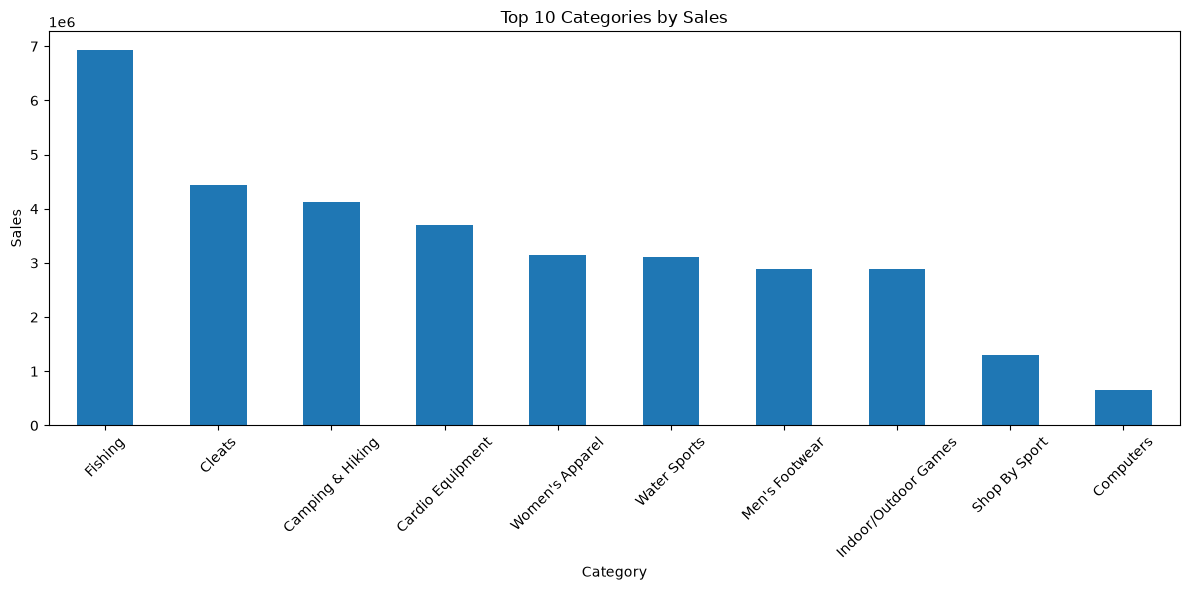

In [124]:
# Sales by Category
category_sales = (
    df.groupby("category_name")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
category_sales.plot(kind="bar")
plt.title("Top 10 Categories by Sales")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The highest-selling categories should receive priority in inventory planning to reduce stockout risk.

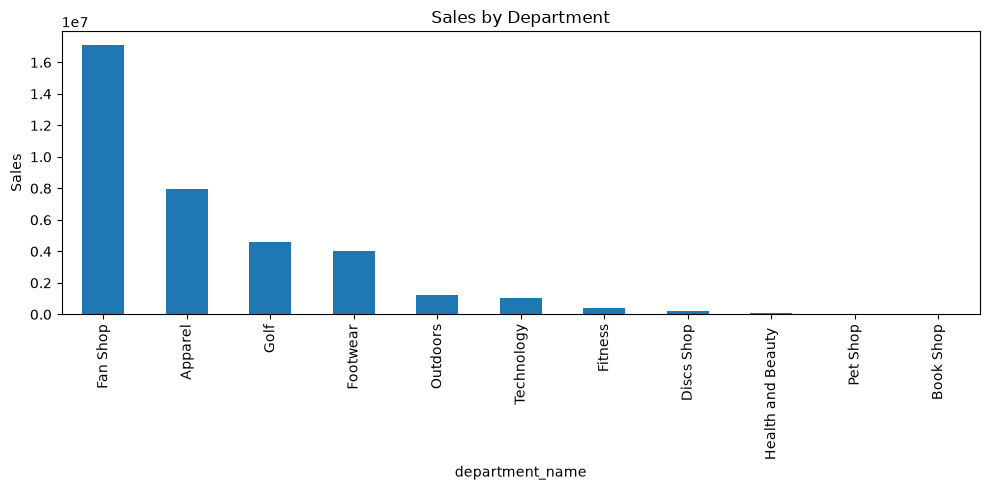

In [125]:
# Sales by Department
department_sales = (
    df.groupby("department_name")["sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
department_sales.plot(kind="bar")
plt.title("Sales by Department")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

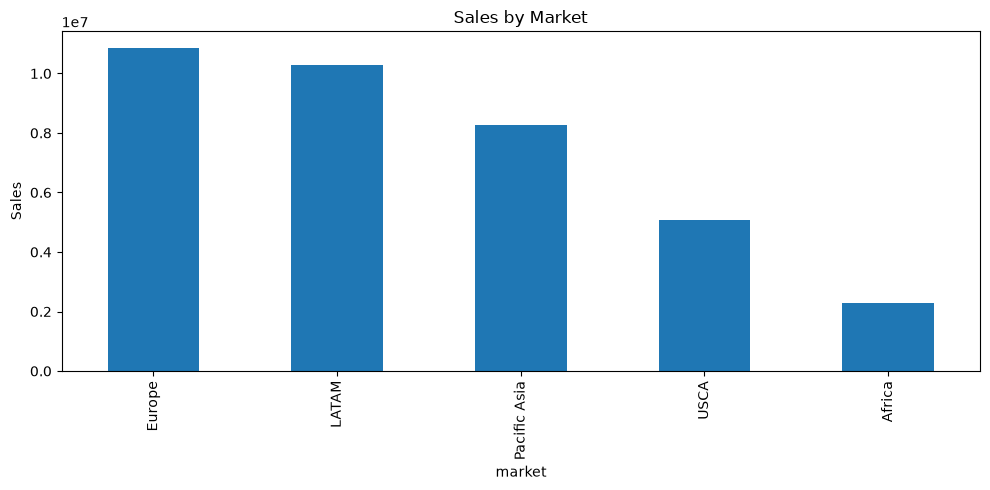

In [126]:
# Sales by Market
market_sales = (
    df.groupby("market")["sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
market_sales.plot(kind="bar")
plt.title("Sales by Market")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

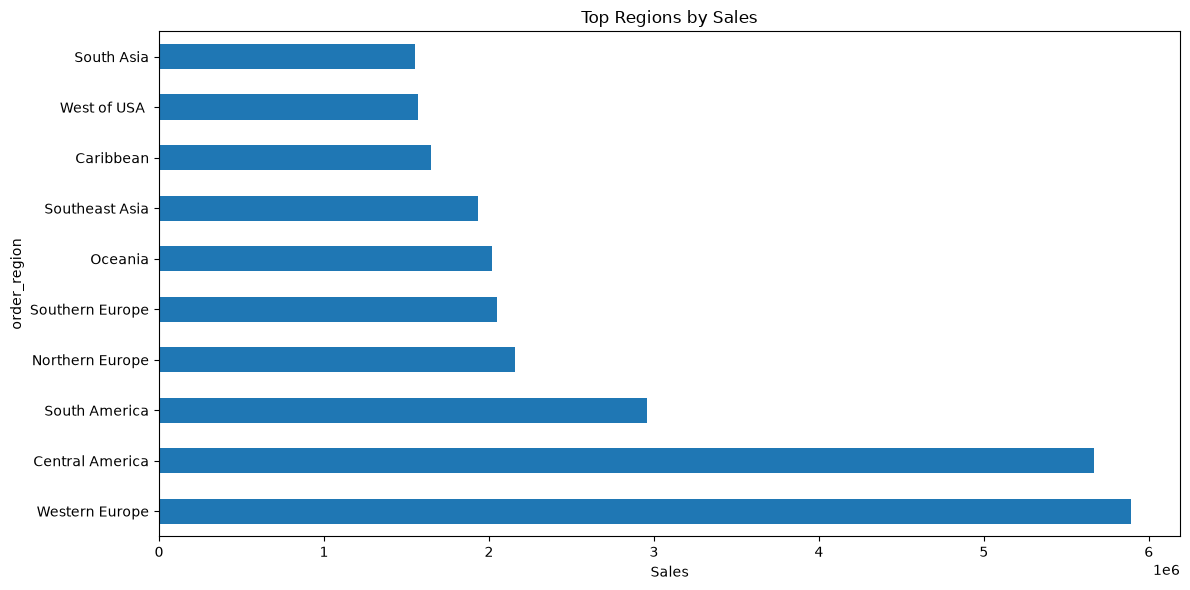

In [103]:
# Sales by Region
region_sales = (
    df.groupby("order_region")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
region_sales.plot(kind="barh")
plt.title("Top Regions by Sales")
plt.xlabel("Sales")
plt.tight_layout()
plt.show()

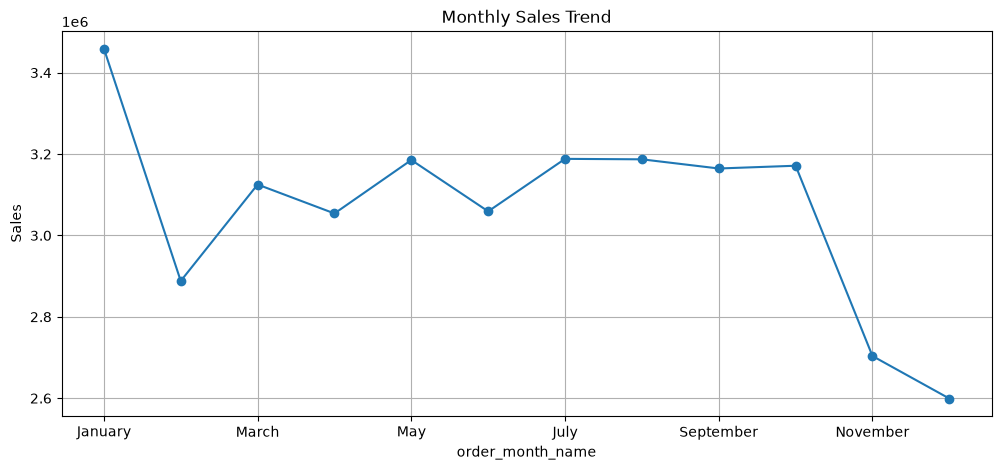

In [104]:
# Monthly Sales Trend
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = (
    df.groupby("order_month_name")["sales"]
      .sum()
      .reindex(month_order)
)

plt.figure(figsize=(12,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

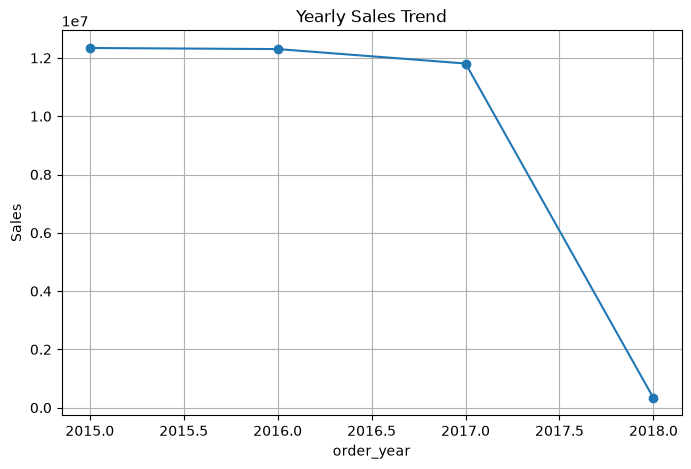

In [105]:
# Yearly Sales Trend
yearly_sales = df.groupby("order_year")["sales"].sum()

plt.figure(figsize=(8,5))
yearly_sales.plot(marker="o")
plt.title("Yearly Sales Trend")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

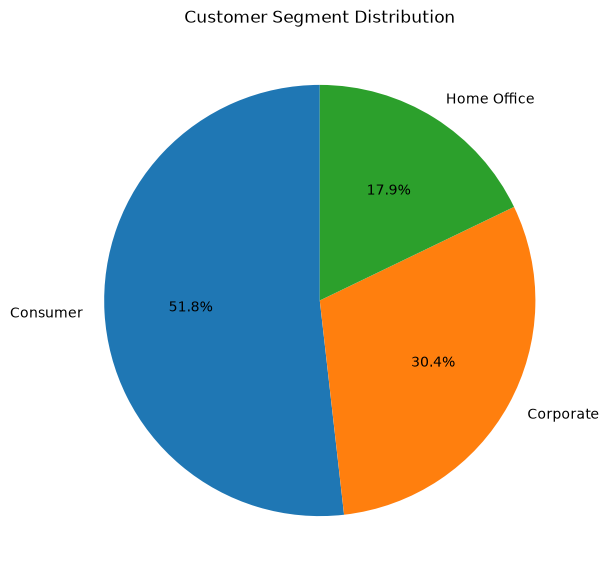

In [106]:
# Customer Segment
segment = df["customer_segment"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    segment,
    labels=segment.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Customer Segment Distribution")
plt.show()

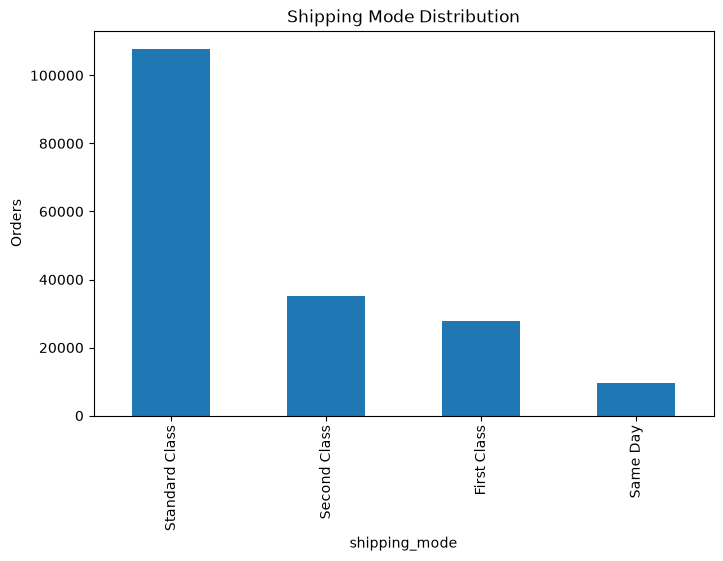

In [107]:
# Shipping Mode
shipping = df["shipping_mode"].value_counts()

plt.figure(figsize=(8,5))
shipping.plot(kind="bar")
plt.title("Shipping Mode Distribution")
plt.ylabel("Orders")
plt.show()

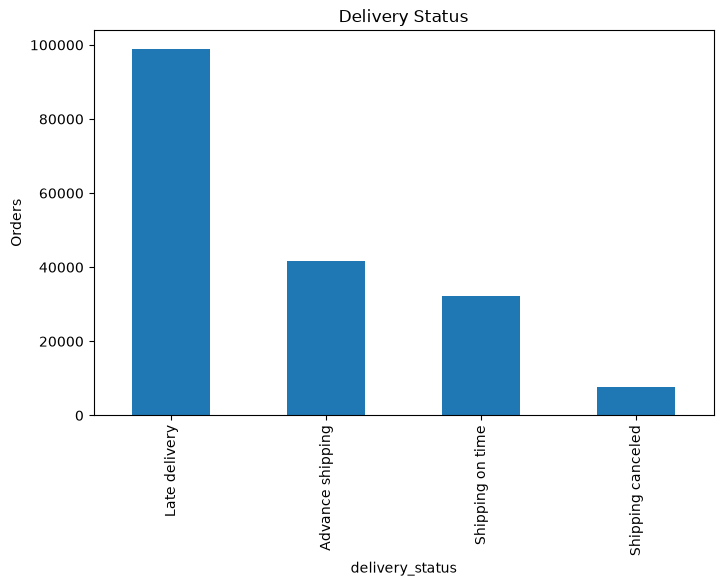

In [108]:
# Delivery Status
delivery = df["delivery_status"].value_counts()

plt.figure(figsize=(8,5))
delivery.plot(kind="bar")
plt.title("Delivery Status")
plt.ylabel("Orders")
plt.show()

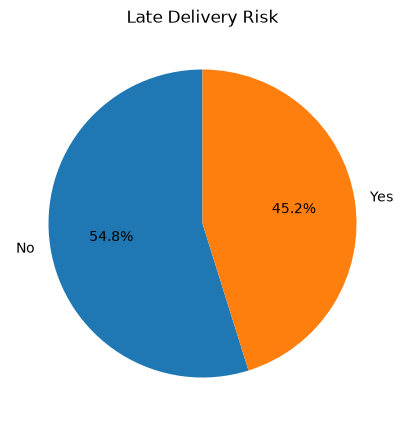

In [109]:
# Late Delivery Risk
late = df["late_delivery_risk"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(
    late,
    labels=["No","Yes"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Late Delivery Risk")
plt.show()

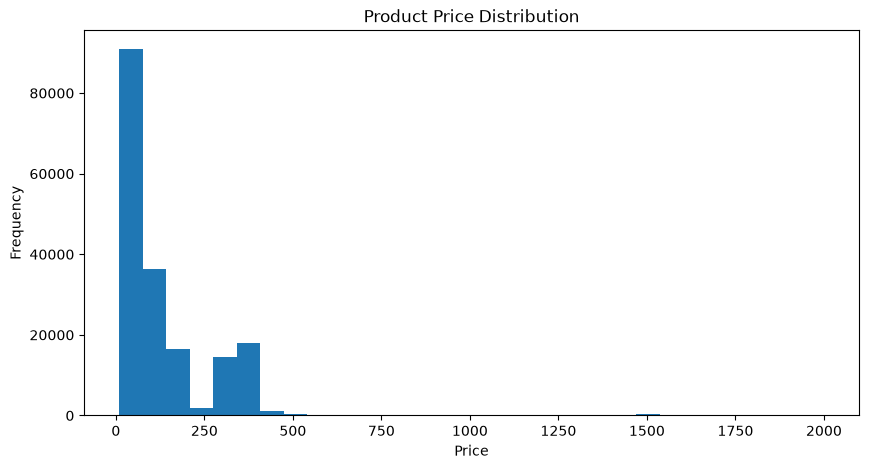

In [110]:
# Product Price Distribution
plt.figure(figsize=(10,5))
plt.hist(df["product_price"], bins=30)
plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

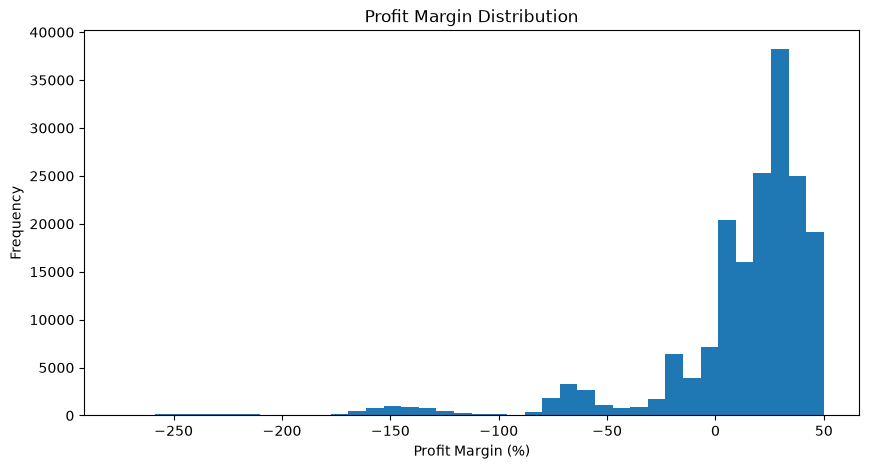

In [111]:
# Profit Margin Distribution
plt.figure(figsize=(10,5))
plt.hist(df["profit_margin"], bins=40)
plt.title("Profit Margin Distribution")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.show()

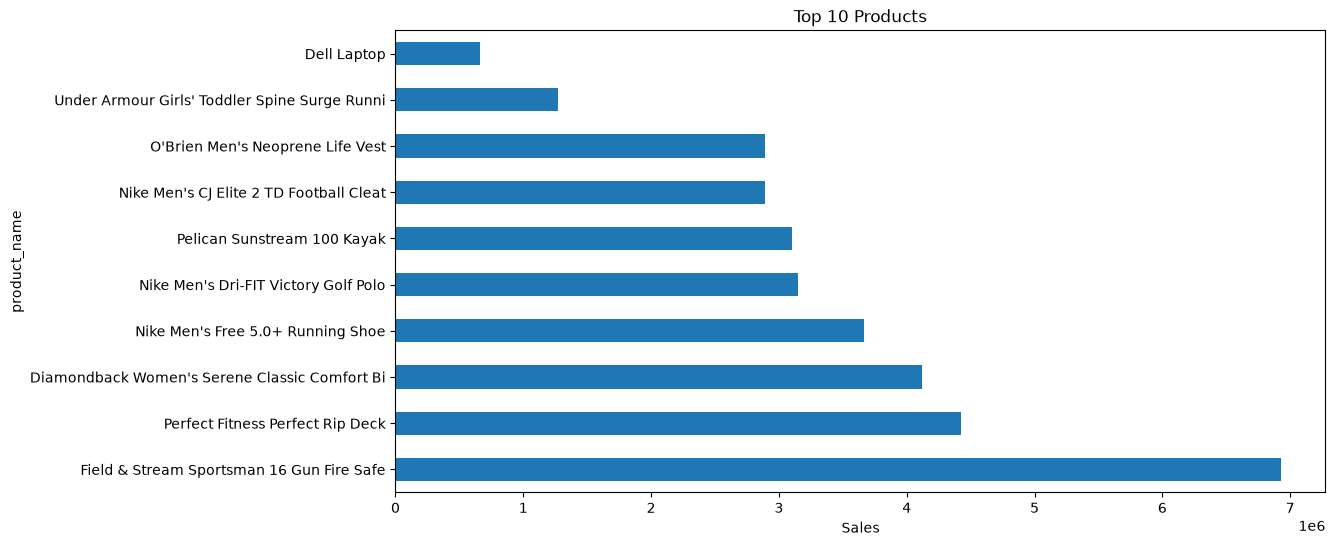

In [112]:
# Top 10 Products
top_products = (
    df.groupby("product_name")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top_products.plot(kind="barh")
plt.title("Top 10 Products")
plt.xlabel("Sales")
plt.show()

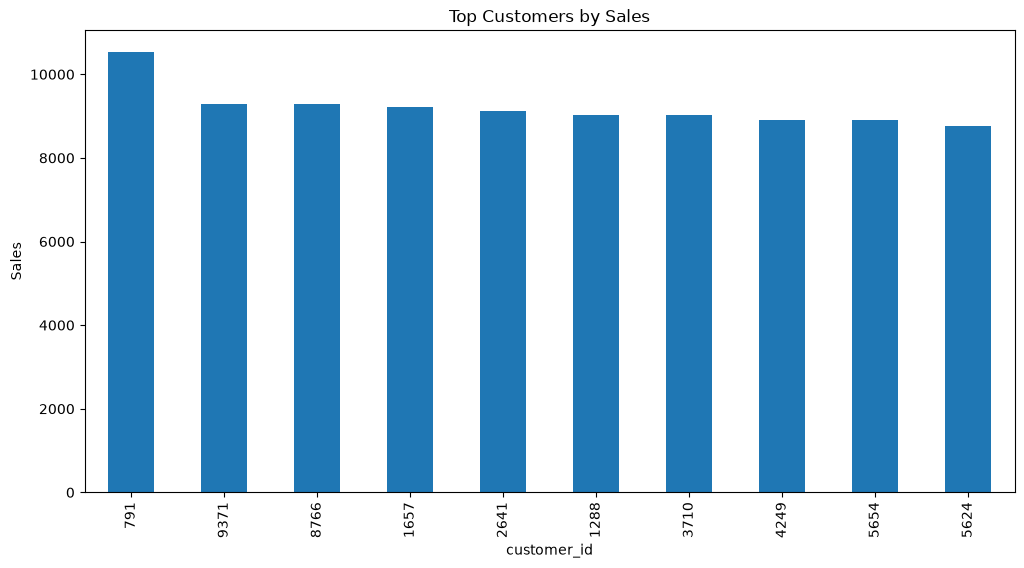

In [113]:
# Top 10 Customers
top_customers = (
    df.groupby("customer_id")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top_customers.plot(kind="bar")
plt.title("Top Customers by Sales")
plt.ylabel("Sales")
plt.show()

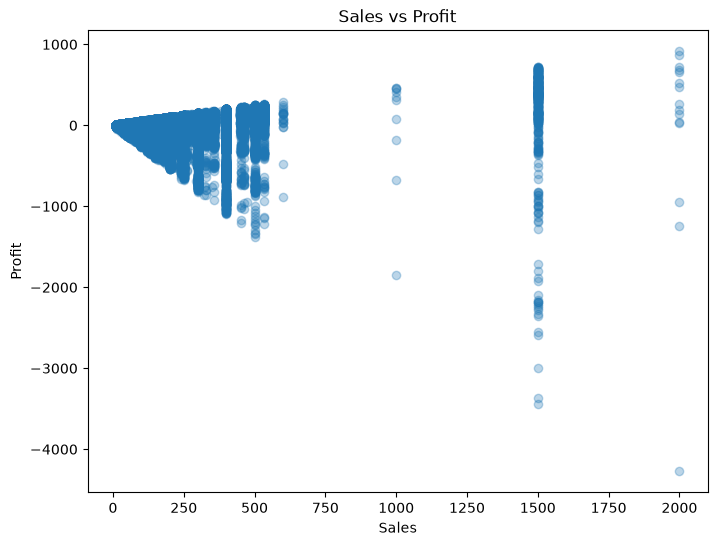

In [114]:
# Sales vs Profit
plt.figure(figsize=(8,6))
plt.scatter(
    df["sales"],
    df["order_profit_per_order"],
    alpha=0.3
)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

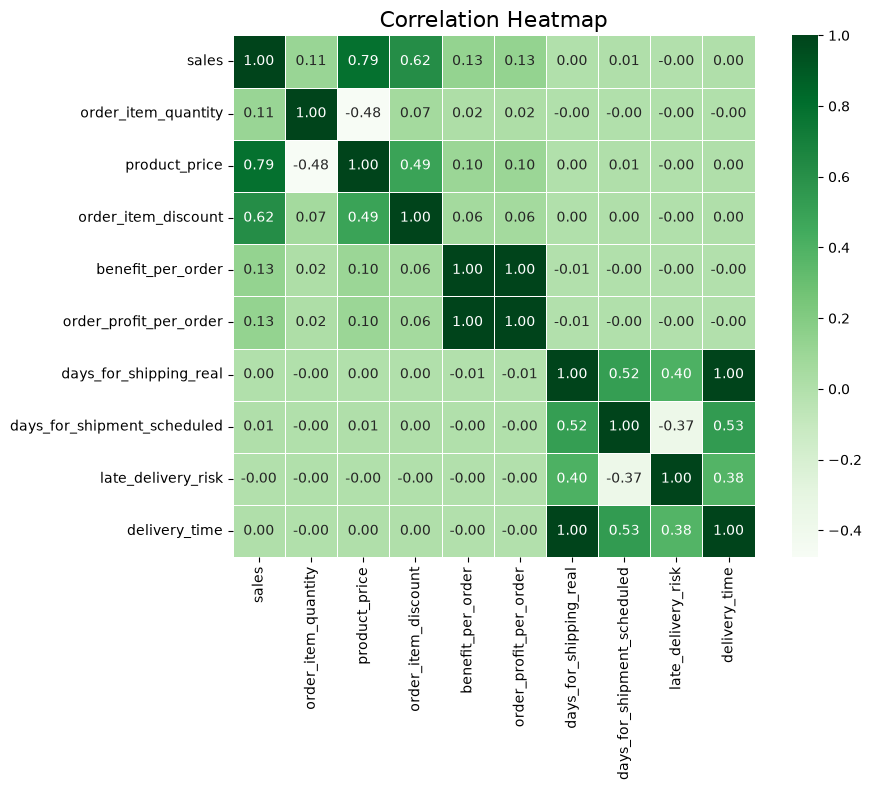

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select important numeric columns
corr = df[
    [
        "sales",
        "order_item_quantity",
        "product_price",
        "order_item_discount",
        "benefit_per_order",
        "order_profit_per_order",
        "days_for_shipping_real",
        "days_for_shipment_scheduled",
        "late_delivery_risk",
        "delivery_time"
    ]
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="Greens",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

In [130]:
## Export Cleaned Dataset
df.to_csv("DataCoSupplyChain_Cleaned(EDA).csv", index=False)